# FRGfp usage

This notebook walks through the whole public API of FRGfp with one complete
example: the O(N) Wilson-Fisher flow at order $\mathcal{O}(\bar{\rho}^8)$ in
the local potential approximation.


## The flow equation

The flow is a user-defined function with the signature `(I, V, dV, ddV, params)`.
It is JIT-compiled with Numba, so define it at module level to enable disk caching.


In [1]:
import math

import numpy as np

import frgfp


def ON_flowrhs(I, V, dV, ddV, params):
    """O(N) flow right-hand side in the local potential approximation."""
    d, N = params
    omega_d = 2.0 / ((4.0 * math.pi) ** (d / 2.0) * math.gamma(d / 2.0))

    return (omega_d / d) * (
        1.0 / (1.0 + dV + 2.0 * I * ddV) + (N - 1.0) / (1.0 + dV)
    ) - d * V + (d - 2.0) * I * dV


## Basis expansions

Use `ChebyshevAnsatz` (orthogonal, on a physical interval) or `PolyAnsatz`
(a Taylor-like expansion around a centre). Both work for an arbitrary number of
invariants.


In [2]:
# 1D Chebyshev basis of order 8 on [0, 0.4] -> 9 coefficients.
ansatz = frgfp.ChebyshevAnsatz(inv_dim=1, order=8, interval=(0.0, 0.4))
print(ansatz.inv_dim, ansatz.num_coeffs)

# 2D polynomial basis of order (2, 2) around (0, 0) -> 9 coefficients.
poly = frgfp.PolyAnsatz(inv_dim=2, order=(2, 2), center=(0.0, 0.0))
print(poly.inv_dim, poly.num_coeffs)


1 9
2 9


## Collocation grids

Grids are 2D arrays of shape `(N_points, inv_dim)` in row-major order. Use
`chebyshev_collgrid` for the basis nodes and `uniform_collgrid` for equidistant
points.


In [3]:
# Chebyshev-Gauss-Lobatto nodes: the natural collocation points of the solver.
coll_grid = frgfp.chebyshev_collgrid(inv_dim=1, num_points=9, interval=(0.0, 0.4))

# Equidistant grid: convenient for fitting a function from sampled values.
fit_grid = frgfp.uniform_collgrid(inv_dim=1, num_points=9, interval=(0.0, 0.4))

print(coll_grid.shape, fit_grid.shape)


(9, 1) (9, 1)


## Function expansions

`FuncFromAnsatz` represents a function expanded in the basis of an ansatz. The
coefficients can be given explicitly, or fitted to sampled values with
`from_grid`, which solves the least-squares problem through Eigen's SVD
pseudo-inverse.


In [4]:
def perturb(rho):
    """Perturbative profile used as the initial guess."""
    return (-0.341419 * rho + 0.876914 * rho**2 + 1.45014 * rho**3
            + 1.5513 * rho**4 - 0.167052 * rho**5 - 1.55923 * rho**6
            + 10.488 * rho**7 + 37.6868 * rho**8 + 0.0683767)


fit = frgfp.FuncFromAnsatz.from_grid(
    ansatz=ansatz, grid=fit_grid, vals=perturb(fit_grid))

print(fit.num_coeffs, fit.coeffs.shape)
print(fit.evaluate(fit_grid))
print(fit.evaluate_grad(fit_grid)[0])
print(fit.evaluate_hess(fit_grid)[0])


9 (9,)
[0.0683767  0.05368893 0.04460741 0.04257112 0.04933014 0.06721866
 0.09981631 0.1532468  0.23842232]
[-0.341419   -0.24208266 -0.11640031  0.04070031  0.23723261  0.48982224
  0.83376551  1.33866236  2.13081081]
[ 1.753828    2.23486965  2.80856469  3.50033782  4.41307685  5.80300808
  8.17931423 12.42749518 19.95647128]


In [5]:
# The constructor takes an explicit coefficient vector, and `coeffs` can be
# updated in place.
func = frgfp.FuncFromAnsatz(ansatz=ansatz, coeffs=fit.coeffs)
func.coeffs = 0.5 * fit.coeffs
print(func.ansatz.num_coeffs)


9


In [6]:
# evaluate_rhs evaluates the expansion, its derivatives and the flow equation.
x = np.linspace(0.0, 0.4, 100)
rhs = fit.evaluate_rhs(x, 1, ON_flowrhs, (3.0, 8.0))
print(rhs.shape)


(100,)


## Solving an LPA fixed point

`LPACollSolver` performs the Newton-Gauss iteration. It takes the collocation
grid, the ansatz, the flow function and the two dimensions: `inv_dim`
(invariants) and `param_dim` (flow parameters).


In [7]:
solver = frgfp.lpa.LPACollSolver(
    ansatz=ansatz, coll_grid=coll_grid, flowrhs_func=ON_flowrhs,
    inv_dim=1, param_dim=2)

print(solver.inv_dim, solver.param_dim)

fixed_point = solver.local_optimize(
    init_coeffs=fit.coeffs, flow_params=(3.0, 8.0),
    maxiter=1000, tol=1e-8, multithread=True)

print(fixed_point.evaluate(coll_grid))


1 2
[0.06775621 0.06285866 0.05142193 0.04270427 0.04916902 0.07923783
 0.12792701 0.17449585 0.19380147]


In [8]:
# At the fixed point the right-hand side of the flow vanishes.
residual = fixed_point.evaluate_rhs(coll_grid, 1, ON_flowrhs, (3.0, 8.0))
print(np.max(np.abs(residual)))


1.885880340779522e-11


In [9]:
# A fixed number of iterations, without a convergence criterion.
stepped = solver.local_optimize_fixed_iterations(
    init_coeffs=fit.coeffs, flow_params=(3.0, 8.0),
    num_iter=3, multithread=True)

# Follow a path of flow parameters, restarting from the previous solution.
path = solver.param_path_following(
    init_coeffs=fixed_point.coeffs,
    flow_params_path=[(3.0, 8.0), (3.0, 9.0)],
    maxiter=1000, tol=1e-8, multithread=True)

# Several initial guesses at once (the starts run in parallel).
starts = solver.multistart_optimize(
    init_coeffs_list=[fixed_point.coeffs, fit.coeffs],
    flow_params=(3.0, 8.0), maxiter=1000, tol=1e-8)

print([fp is not None for fp in path])
print([fp is not None for fp in starts])


[True, True]
[True, True]


## Comparison with the perturbative input

The fixed point and the perturbative starting profile are compared on a dense
grid, and the right-hand side of the flow is shown on a logarithmic scale.
(The plot needs `matplotlib`, which is not a dependency of FRGfp.)


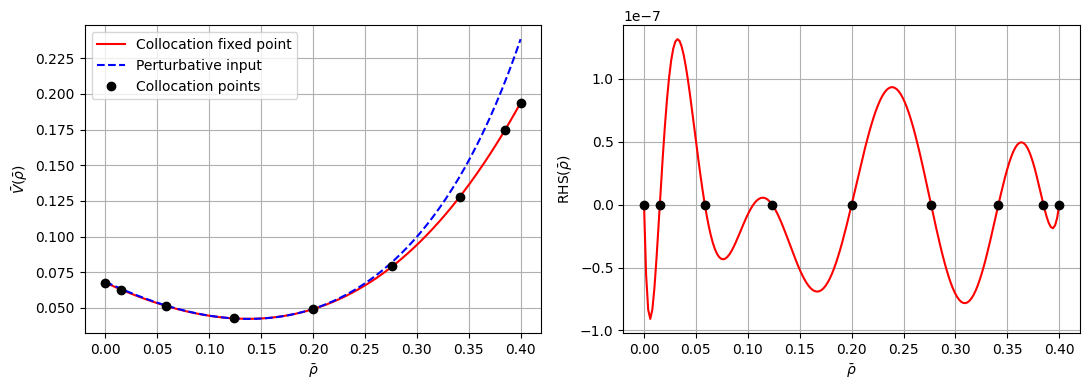

In [10]:
import matplotlib.pyplot as plt

x = np.linspace(0.0, 0.4, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(x, fixed_point.evaluate(x), color="red", label="Collocation fixed point")
ax1.plot(x, perturb(x), "--", color="blue", label="Perturbative input")
ax1.plot(coll_grid, fixed_point.evaluate(coll_grid), "o", color="black",
         label="Collocation points")
ax1.set_xlabel(r"$\bar{\rho}$")
ax1.set_ylabel(r"$\bar{V}(\bar{\rho})$")
ax1.grid()
ax1.legend()

ax2.plot(x, fixed_point.evaluate_rhs(x, 1, ON_flowrhs, (3.0, 8.0)),
         color="red")
ax2.plot(coll_grid, fixed_point.evaluate_rhs(coll_grid, 1, ON_flowrhs, (3.0, 8.0)), "o", color="black",
         label="Collocation points")
ax2.set_xlabel(r"$\bar{\rho}$")
ax2.set_ylabel(r"$\mathrm{RHS}(\bar{\rho})$")
ax2.grid()

fig.tight_layout()
plt.show()
